In [1]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf

Importo la respuesta al impulso

In [3]:
imp,fs = sf.read('rta_imp.wav')

La grafico, para ver que no me hayan mentido

Text(0, 0.5, 'Amplitud')

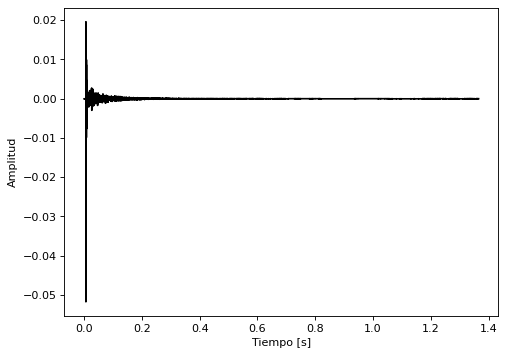

In [4]:
t = np.arange(start = 0,stop = len(imp)/fs,step=1/fs)
fig,ax = plt.subplots(figsize=(7,5)  , dpi=80)
ax.plot(t,imp,color='black')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('Amplitud')

Algo de zoom para ver lo que importa

Text(0, 0.5, 'Amplitud')

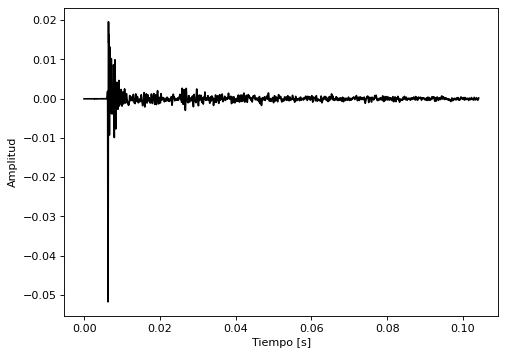

In [5]:
t = np.arange(start = 0,stop = len(imp)/fs,step=1/fs)
fig,ax = plt.subplots(figsize=(7,5)  , dpi=80)
ax.plot(t[:5000],imp[:5000],color='black')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('Amplitud')

Perfecto, entonces voy a recortar la respuesta al impulso como me dijeron en el enunciado para minimizar la influencia del recinto.

In [6]:
imp_index = np.argmax(imp) #busco el índice del máximo
print(t[imp_index]) #veo a qué tiempo corresponde

0.0064375


Corto un poco para atrás para sacarme de encima los ceros, y 5 ms después para sacarme de encima al cuarto.

In [7]:
t_max = t[imp_index] + 0.005 # 5 ms para adelante
t_min = t[imp_index] - 0.0004 # 0.1 ms para atrás
#busco los índices a los cuales corresponden esos tiempos
index_t_max = np.where(t==t_max)[0][0]
index_t_min = np.where(t==t_min)[0][0]


IndexError: index 0 is out of bounds for axis 0 with size 0

Ok, alguno de los dos valores temporales no están en mi vector de tiempos, pruebo el máximo

In [8]:
index_t_max = np.where(t==t_max)[0][0]

Entonces es el mínimo, busco el más cercano

In [9]:
index_t_min = np.abs(t - t_min).argmin()
print(t[index_t_min])
print(t_min)

0.0060416666666666665
0.0060374999999999995


Bastante bien

Ahora que tengo los dos índices, recorto la respuesta al impulso y la grafico

Text(0, 0.5, 'Amplitud')

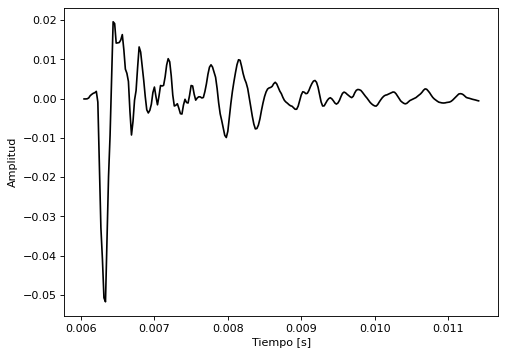

In [10]:
imp_recortada = imp[index_t_min:index_t_max]
fig,ax = plt.subplots(figsize=(7,5)  , dpi=80)
ax.plot(t[index_t_min:index_t_max],imp_recortada,color='black')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('Amplitud')


Aplico la FFT a mi respuesta al impulso ventaneada

In [11]:
imp_fft = np.fft.rfft(imp_recortada)
f = np.arange(start = 0,stop = fs//2,step=(fs//2)/len(imp_fft))
print(len(f))
print(len(imp_fft))

130
130


Grafico el espectro

Text(0, 0.5, 'Amplitud')

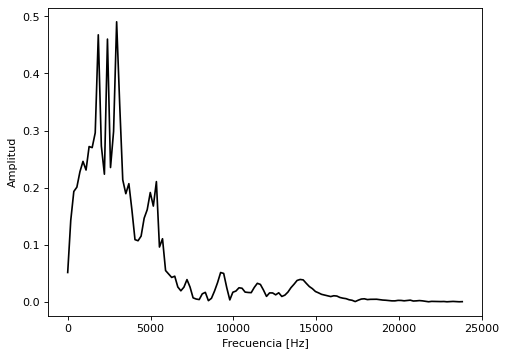

In [12]:
fig,ax = plt.subplots(figsize=(7,5)  , dpi=80)
ax.plot(f,np.abs(imp_fft),color='black')
ax.set_xlabel('Frecuencia [Hz]')
ax.set_ylabel('Amplitud')

Parece todo bastante normal, ¿no?

Pero, momento, acabo de representar 26000 Hz con 130 puntos nada más! 

In [13]:
print(f[0])
print(f[1])
print(f[2])

0.0
184.6153846153846
369.2307692307692


Cada muestra de mi transformada representa un salto de 184 Hz, lo cual queda claro si recordamos que la resolución en frecuencia viene dada por:
$$ \Delta_f = \frac{f_s}{N}$$

donde $f_s$ es la frecuencia de muestreo, en nuestro caso 48 kHz, y $N$ es la longitud de nuestra transformada, en nuestro caso 260.

In [14]:
delta_f = fs/260
print(delta_f)

184.6153846153846


Nuestro sistema bajo análisis es un parlante, entonces hay un montón de información en baja frecuencia que no estamos viendo por la pésima resolución frecuencial que tenemos.

Evidentemente nuestro método para sacarnos de encima al cuarto está bueno pero así como está no sirve. ¿Alguna solución?